In [115]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [116]:
!pip install kagglehub[pandas-datasets]

In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
train_path = "twitter_training.csv"
vald_path = "twitter_validation.csv"

# Load the latest version
train_df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "jp797498e/twitter-entity-sentiment-analysis",
  train_path,
  pandas_kwargs={"header": None}
)

valid_df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "jp797498e/twitter-entity-sentiment-analysis",
  vald_path,
  pandas_kwargs={"header": None}
)
df = pd.concat([train_df, valid_df], ignore_index=True)

print("First 5 records:", df.head())

First 5 records:       0            1         2  \
0  2401  Borderlands  Positive   
1  2401  Borderlands  Positive   
2  2401  Borderlands  Positive   
3  2401  Borderlands  Positive   
4  2401  Borderlands  Positive   

                                                   3  
0  im getting on borderlands and i will murder yo...  
1  I am coming to the borders and I will kill you...  
2  im getting on borderlands and i will kill you ...  
3  im coming on borderlands and i will murder you...  
4  im getting on borderlands 2 and i will murder ...  


In [118]:
df.columns=['id','information','label','tweet']
df.head()

,id,information,label,tweet
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


# EDA

## Number of Null Values in each column

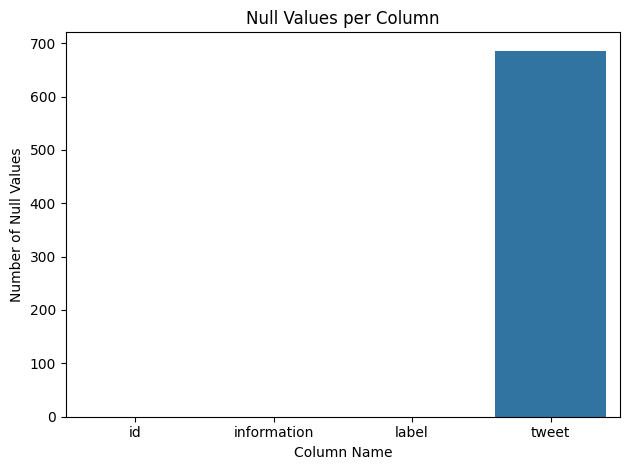

In [119]:
import seaborn as sns
import matplotlib.pyplot as plt

# Count nulls per column
null_counts = df.isnull().sum().reset_index()
null_counts.columns = ['column', 'null_count']
# Plot null counts
sns.barplot(
    data=null_counts,
    x='column',
    y='null_count',
)

plt.xlabel('Column Name')
plt.ylabel('Number of Null Values')
plt.title('Null Values per Column')
plt.tight_layout()
plt.show()


In [120]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75682 entries, 0 to 75681
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           75682 non-null  int64 
 1   information  75682 non-null  object
 2   label        75682 non-null  object
 3   tweet        74996 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


### Removing Null Values

In [121]:
df.dropna(inplace=True)

## Number of each sentiment class

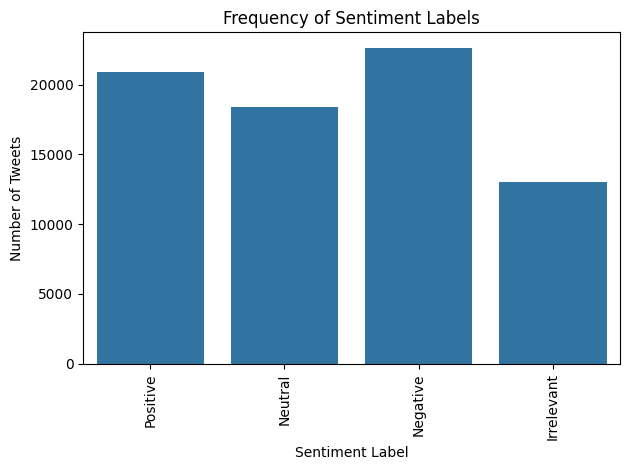

In [122]:
sns.countplot(data=df, x="label")
plt.xticks(rotation=90)
plt.title("Frequency of Sentiment Labels")
plt.xlabel("Sentiment Label")
plt.ylabel("Number of Tweets")
plt.tight_layout()
plt.show()


## Distribution of tweets per Branch and Label

In [123]:
plot=df.groupby(by=["information","label"]).count().reset_index()
plot.head()

,information,label,id,tweet
0,Amazon,Irrelevant,189,189
1,Amazon,Negative,581,581
2,Amazon,Neutral,1225,1225
3,Amazon,Positive,315,315
4,ApexLegends,Irrelevant,195,195


Text(0.5, 1.0, 'Distribution of tweets per Branch and Label')

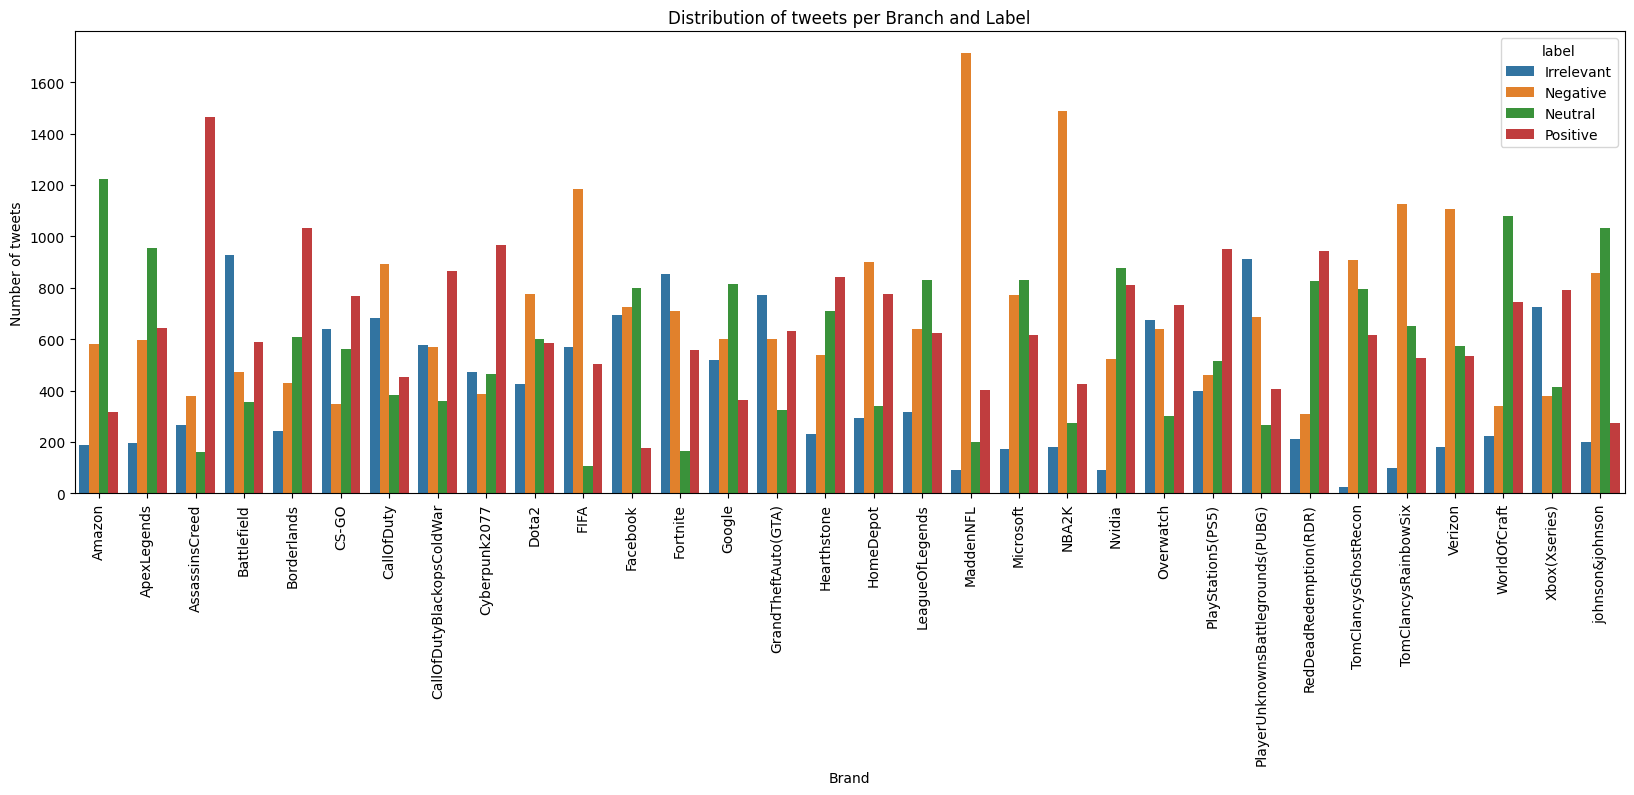

In [124]:
#Figure of comparison per label
plt.figure(figsize=(20,6))
sns.barplot(data=plot,x="information",y="id",hue="label")
plt.xticks(rotation=90)
plt.xlabel("Brand")
plt.ylabel("Number of tweets")
plt.title("Distribution of tweets per Branch and Label")

# Text Preprocessing

In [125]:
import nltk
import string

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Initialize the lemmatizer
wnl = WordNetLemmatizer()

def preprocessing(raw_text):
  stop_words = set(stopwords.words("english"))

  raw_text = str(raw_text)
  # Use word_tokenize for better tokenization before lemmatization
  words = word_tokenize(raw_text.lower())

  filtered_words = [word for word in words if word not in stop_words and word not in string.punctuation]
  lemmas = [wnl.lemmatize(word,pos="v") for word in filtered_words]
  return " ".join(lemmas)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\prajw\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\prajw\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\prajw\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\prajw\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [126]:
df['Preprocessed_Text'] = df['tweet'].apply(preprocessing)
df.sample(7)

,id,information,label,tweet,Preprocessed_Text
29538,679,ApexLegends,Irrelevant,Can’t even send a message in peace pic.twitter...,’ even send message peace pic.twitter.com/hzf5...
44972,11723,Verizon,Negative,You're paying for the most expensive @ Verizon...,'re pay expensive verizon plan network book
42899,10158,PlayerUnknownsBattlegrounds(PUBG),Negative,pubg and taehyung... i hate that way,pubg taehyung ... hate way
25733,816,AssassinsCreed,Positive,CAN'T W,ca n't w
39947,1257,Battlefield,Positive,.. Phantom Bow + Dragon Trap - Match 5. Worst ...,.. phantom bow dragon trap match 5. worst call...
4361,1950,CallOfDutyBlackopsColdWar,Positive,This looks like,look like
50119,6204,FIFA,Positive,Let's hope there are some fantastic ones out t...,let 's hope fantastic ones


# Word Clouds

In [127]:
tweet = df["tweet"]
all_text = tweet.str.cat(sep=" ").lower()

tweet = df[df["label"]=="Positive"]["tweet"]
positive_text = tweet.str.cat(sep=" ").lower()

tweet = df[df["label"]=="Negative"]["tweet"]
negative_text = tweet.str.cat(sep=" ").lower()

tweet = df[df["label"]=="Neutral"]["tweet"]
neutral_text = tweet.str.cat(sep=" ").lower()

tweet = df[df["label"]=="Irrelevant"]["tweet"]
irrelevant_text = tweet.str.cat(sep=" ").lower()

In [128]:
from wordcloud import WordCloud #Word visualization

In [129]:
def generate_word_cloud(text,title="Tweets"):
  #Creation of wordcloud
  wordcloud = WordCloud(
    width=1500,
    height=1000,
    max_words=150,
    random_state=42,
    collocations=False,
    background_color="white"
  ).generate(text)

  #Figure properties
  plt.figure(figsize=(14,8))
  plt.imshow(wordcloud, interpolation="bilinear")
  plt.axis("off")
  plt.title(f"Word Cloud For: {title}", fontsize=40)
  plt.show()




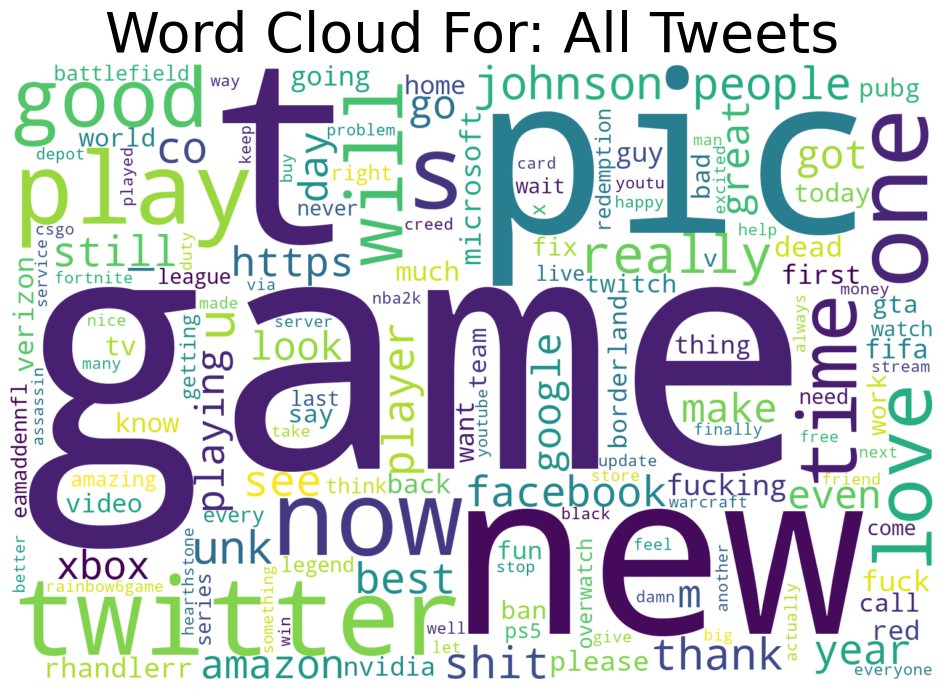

In [130]:
generate_word_cloud(all_text,"All Tweets")

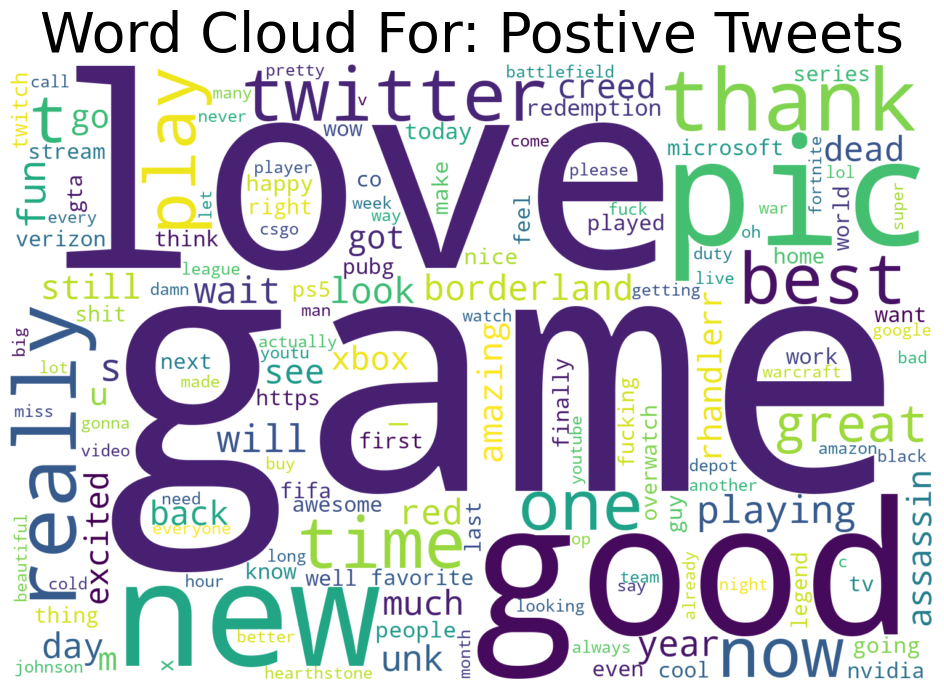

In [131]:
generate_word_cloud(positive_text,"Postive Tweets")

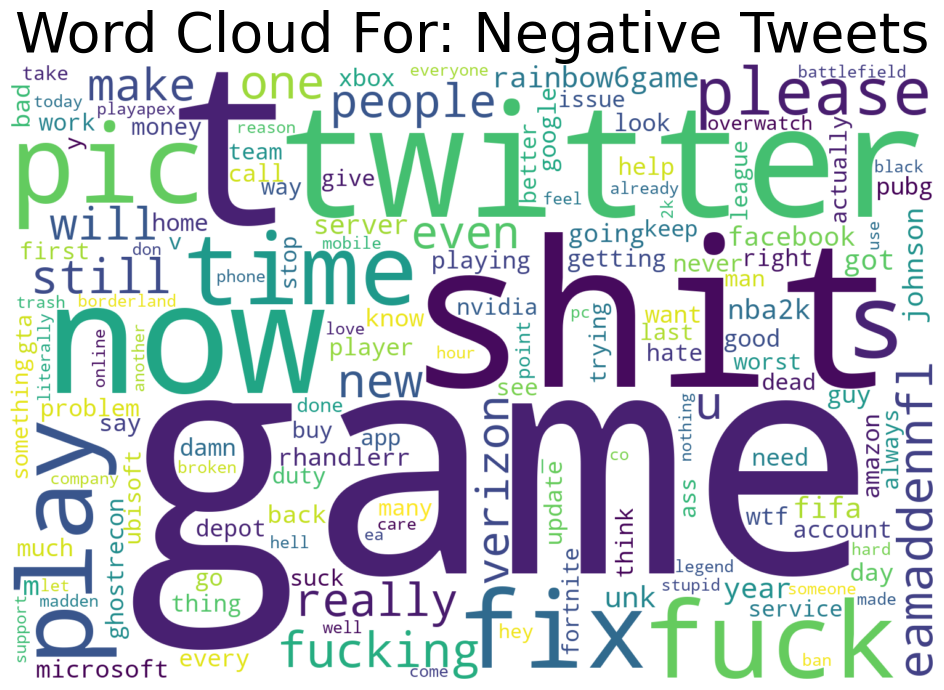

In [132]:
generate_word_cloud(negative_text,"Negative Tweets")

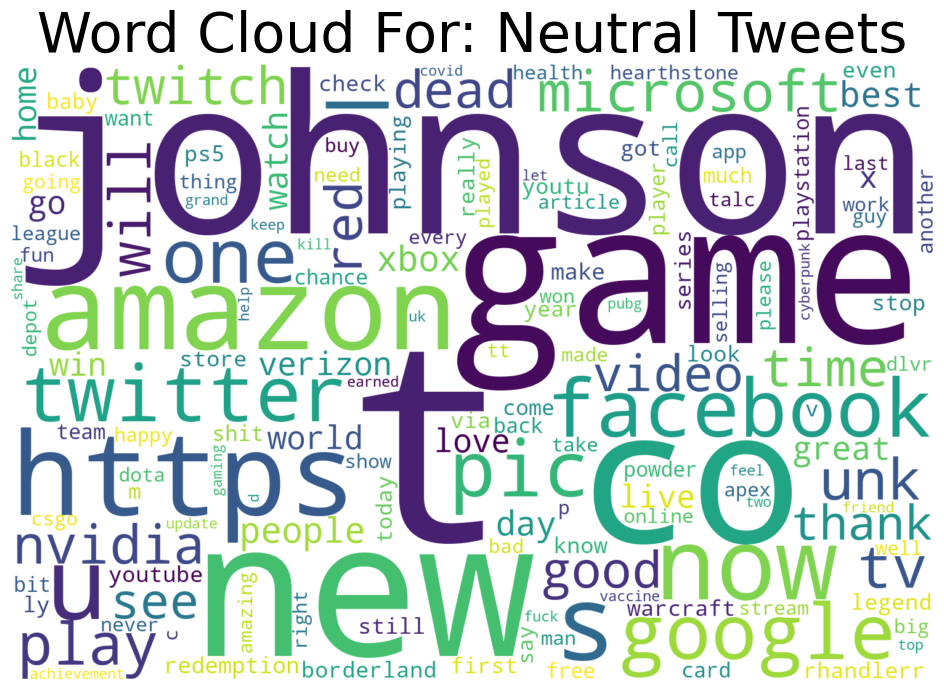

In [133]:
generate_word_cloud(neutral_text,"Neutral Tweets")

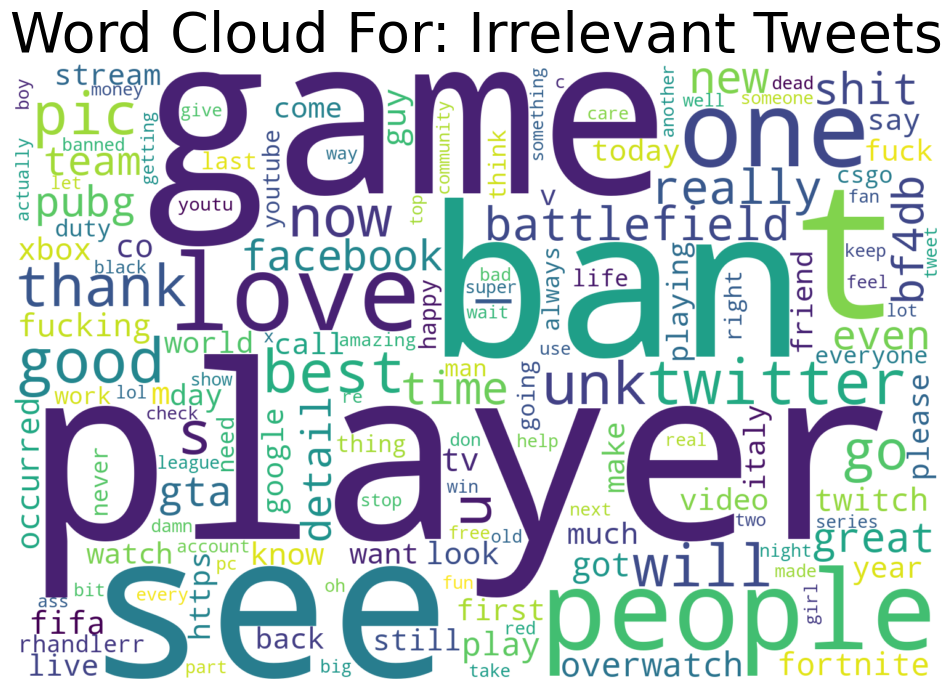

In [134]:
generate_word_cloud(irrelevant_text,"Irrelevant Tweets")

# Preprocessing

## Label Encoding

In [135]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['label'] = le.fit_transform(df['label'])

In [136]:
df

,id,information,label,tweet,Preprocessed_Text
0,2401,Borderlands,3,im getting on borderlands and i will murder yo...,im get borderlands murder
1,2401,Borderlands,3,I am coming to the borders and I will kill you...,come border kill
2,2401,Borderlands,3,im getting on borderlands and i will kill you ...,im get borderlands kill
3,2401,Borderlands,3,im coming on borderlands and i will murder you...,im come borderlands murder
4,2401,Borderlands,3,im getting on borderlands 2 and i will murder ...,im get borderlands 2 murder
...,...,...,...,...,...
75677,4891,GrandTheftAuto(GTA),0,⭐️ Toronto is the arts and culture capital of ...,⭐️ toronto arts culture capital canada ’ wonde...
75678,4359,CS-GO,0,tHIS IS ACTUALLY A GOOD MOVE TOT BRING MORE VI...,actually good move tot bring viewers one peopl...
75679,2652,Borderlands,3,Today sucked so it’s time to drink wine n play...,today suck ’ time drink wine n play borderland...
75680,8069,Microsoft,3,Bought a fraction of Microsoft today. Small wins.,buy fraction microsoft today small win


## Train Test Split

In [137]:
from sklearn.model_selection import train_test_split
X = df[['Preprocessed_Text']]
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)


In [138]:
X_train.shape,X_test.shape

((56247, 1), (18749, 1))

In [139]:
y_train.shape,y_test.shape

((56247,), (18749,))

# Feature Engineering

In [140]:
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

## Count Vectorizer

In [141]:
# Unigram
cv = ColumnTransformer(
    [("cv", CountVectorizer(), 'Preprocessed_Text')]
)

# Bigram
cv_bigram = ColumnTransformer(
    [("cv_bigram", CountVectorizer(ngram_range=(2, 2)), 'Preprocessed_Text')]
)

## TF-IDF Vectorizer

In [142]:
# Unigram
tfidf = ColumnTransformer(
    [("tfidf", TfidfVectorizer(), 'Preprocessed_Text')]
)

# Bigram
tfidf_bigram = ColumnTransformer(
    [("tfidf_bigram", TfidfVectorizer(ngram_range=(2, 2)), 'Preprocessed_Text')]
)

# Training Model

In [143]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

## Random Forest

In [144]:
random_forest = RandomForestClassifier(random_state=42, n_jobs=-1)

### Creating the Pipeline

#### Count Vector Pipeline

In [145]:
random_forest_cv = Pipeline([
    ('cv', cv),
    ('random_forest', RandomForestClassifier(random_state=42, n_jobs=-1))
])

random_forest_cv_bigram = Pipeline([
    ('cv_bigram', cv_bigram),
    ('random_forest', RandomForestClassifier(random_state=42, n_jobs=-1)),
])

#### TF-IDF Pipeline

In [146]:
random_forest_tfidf = Pipeline([
    ('tfidf', tfidf),
    ('random_forest', RandomForestClassifier(random_state=42, n_jobs=-1)),
])

random_forest_tfidf_bigram = Pipeline([
    ('tfidf_bigram', tfidf_bigram),
    ('random_forest', RandomForestClassifier(random_state=42, n_jobs=-1)),
])

### Fitting the model

In [147]:
random_forest_cv.fit(X_train, y_train)
random_forest_cv_bigram.fit(X_train, y_train)

Pipeline(steps=[('cv_bigram',
                 ColumnTransformer(transformers=[('cv_bigram',
                                                  CountVectorizer(ngram_range=(2,
                                                                               2)),
                                                  'Preprocessed_Text')])),
                ('random_forest',
                 RandomForestClassifier(n_jobs=-1, random_state=42))])

In [148]:
random_forest_tfidf.fit(X_train, y_train)
random_forest_tfidf_bigram.fit(X_train, y_train)

Pipeline(steps=[('tfidf_bigram',
                 ColumnTransformer(transformers=[('tfidf_bigram',
                                                  TfidfVectorizer(ngram_range=(2,
                                                                               2)),
                                                  'Preprocessed_Text')])),
                ('random_forest',
                 RandomForestClassifier(n_jobs=-1, random_state=42))])

## Naive Bayes

In [149]:
multinomialNB = MultinomialNB()

#### Count Vector Pipeline

In [150]:
multinomialNB_cv = Pipeline([
    ('cv', cv),
    ('multinomialNB', MultinomialNB())
])

multinomialNB_cv_bigram = Pipeline([
    ('cv_bigram', cv_bigram),
    ('multinomialNB', MultinomialNB()),
])

#### TF-IDF Pipeline

In [151]:
multinomialNB_tfidf = Pipeline([
    ('tfidf', tfidf),
    ('multinomialNB', MultinomialNB()),
])

multinomialNB_tfidf_bigram = Pipeline([
    ('tfidf_bigram', tfidf_bigram),
    ('multinomialNB', MultinomialNB()),
])

### Fitting the model

In [152]:
multinomialNB_cv.fit(X_train, y_train)
multinomialNB_cv_bigram.fit(X_train, y_train)

Pipeline(steps=[('cv_bigram',
                 ColumnTransformer(transformers=[('cv_bigram',
                                                  CountVectorizer(ngram_range=(2,
                                                                               2)),
                                                  'Preprocessed_Text')])),
                ('multinomialNB', MultinomialNB())])

In [153]:
multinomialNB_tfidf.fit(X_train, y_train)
multinomialNB_tfidf_bigram.fit(X_train, y_train)

Pipeline(steps=[('tfidf_bigram',
                 ColumnTransformer(transformers=[('tfidf_bigram',
                                                  TfidfVectorizer(ngram_range=(2,
                                                                               2)),
                                                  'Preprocessed_Text')])),
                ('multinomialNB', MultinomialNB())])

#Model Evalutation

## Function for diagram

In [154]:
from sklearn.metrics import accuracy_score, recall_score, precision_score,f1_score,\
                            confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
                            
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize

result_df = pd.DataFrame(
    columns=["model name", "accuracy", "precision", "recall", "f1"]
)

def save_result(y_pred, title=""):
    accuracy = np.round(accuracy_score(y_test, y_pred), 2)
    precision = np.round(precision_score(y_test, y_pred, average="weighted"), 2)
    recall = np.round(recall_score(y_test, y_pred, average="weighted"), 2)
    f1 = np.round(f1_score(y_test, y_pred, average="weighted"), 2)

    result_df.loc[len(result_df)] = [title, accuracy, precision, recall, f1]

# Confusion Matrix
def display_confusion_matrix(y_true, y_pred, title=""):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix for {title}")
    plt.tight_layout()
    plt.show()

# ROC Curve
def display_ROC(y_test, y_prob, classes_, title=""):
    # Binarize the output
    y_test_bin = label_binarize(y_test, classes=classes_)
    plt.figure(figsize=(8, 6))
    for i, class_label in enumerate(classes_):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"Class {class_label} (AUC = {roc_auc:.2f})")

    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"Multi-Class ROC Curve for {title}")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [155]:
from sklearn.metrics import classification_report

def generate_evaluation(model, title=""):
  y_pred = model.predict(X_test)
  y_prob = model.predict_proba(X_test)
  
  print(f"{title} Evaluation:\n")
  print(f"Classification Report:")
  print(classification_report(y_test, y_pred))
  print("\n")
  save_result(y_pred, title)
  display_confusion_matrix(y_test, y_pred, title=title)
  display_ROC(y_test, y_prob, model.classes_, title=title)

# Count Random Forest

Random Forest Count Vectorizer (Unigram) Evaluation:

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.86      0.91      3262
           1       0.87      0.95      0.91      5656
           2       0.95      0.89      0.92      4598
           3       0.90      0.92      0.91      5233

    accuracy                           0.91     18749
   macro avg       0.92      0.90      0.91     18749
weighted avg       0.91      0.91      0.91     18749





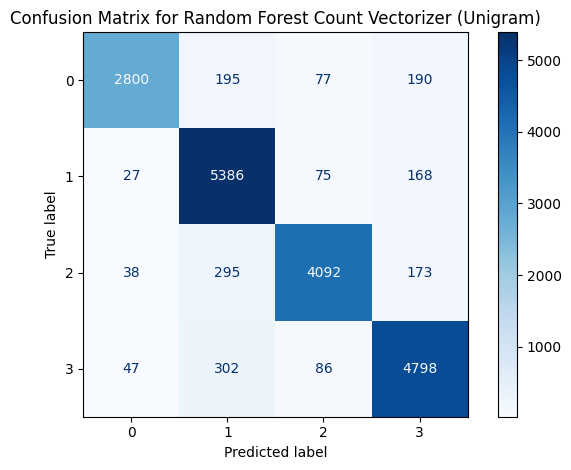

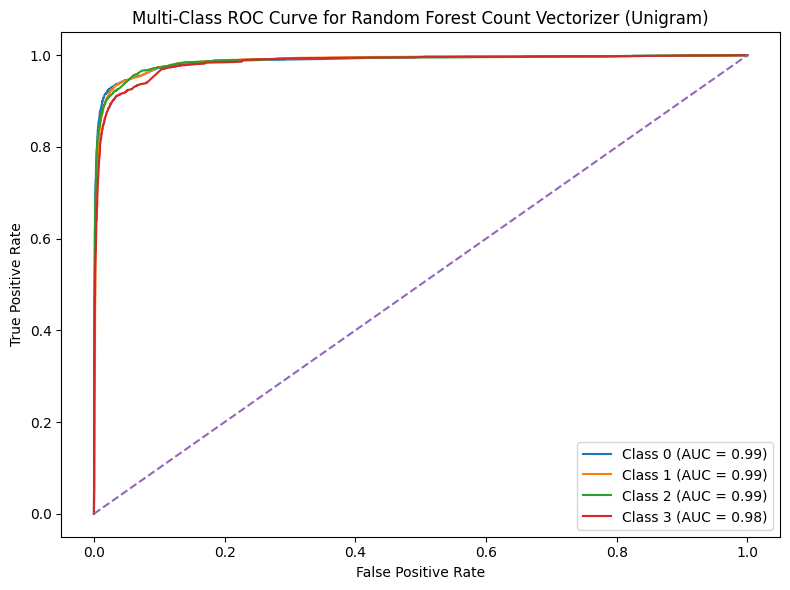

In [156]:
generate_evaluation(random_forest_cv, "Random Forest Count Vectorizer (Unigram)")

Random Forest Count Vectorizer (Bigram) Evaluation:

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.77      0.85      3262
           1       0.89      0.84      0.87      5656
           2       0.91      0.82      0.86      4598
           3       0.73      0.93      0.82      5233

    accuracy                           0.85     18749
   macro avg       0.87      0.84      0.85     18749
weighted avg       0.86      0.85      0.85     18749





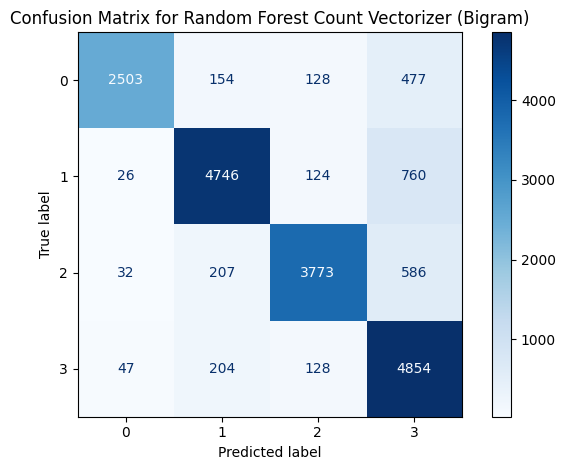

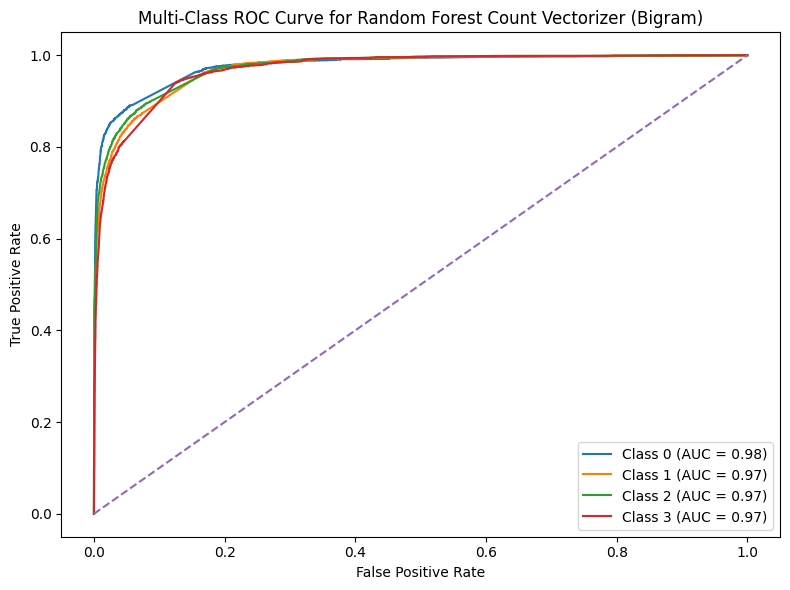

In [157]:
generate_evaluation(random_forest_cv_bigram, "Random Forest Count Vectorizer (Bigram)")

# TF-IDF Random Forest

Random Forest TF-IDF (Unigram) Evaluation:

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.86      0.92      3262
           1       0.87      0.95      0.91      5656
           2       0.94      0.89      0.92      4598
           3       0.90      0.92      0.91      5233

    accuracy                           0.91     18749
   macro avg       0.92      0.91      0.91     18749
weighted avg       0.92      0.91      0.91     18749





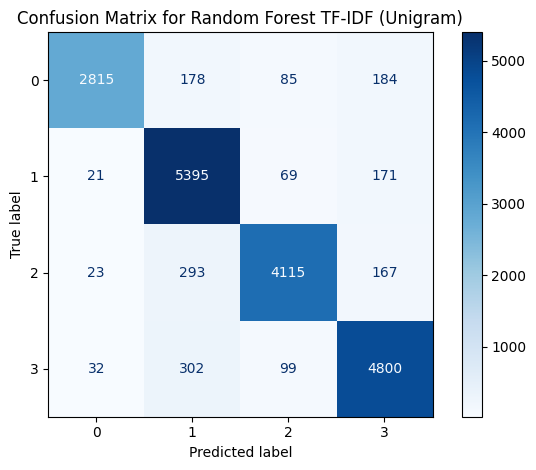

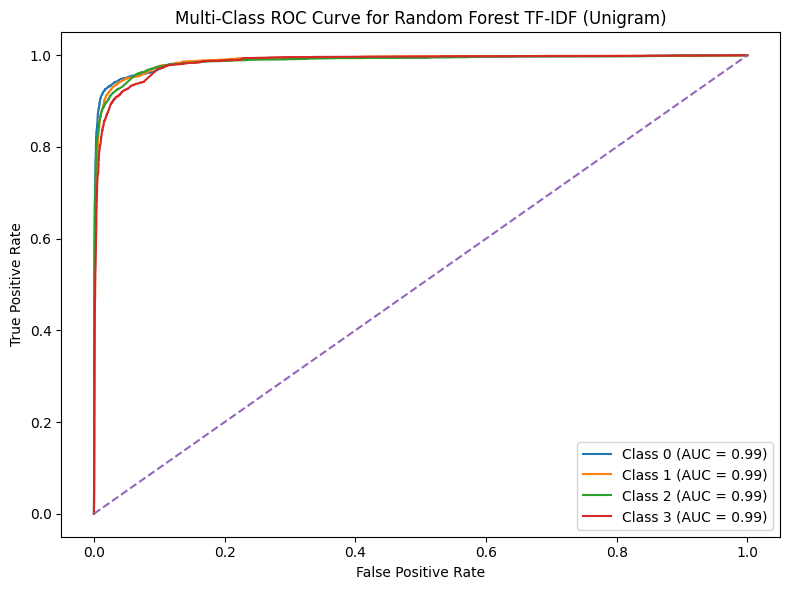

In [158]:
generate_evaluation(random_forest_tfidf, "Random Forest TF-IDF (Unigram)")

Random Forest TF-IDF (Bigram) Evaluation:

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.76      0.85      3262
           1       0.89      0.84      0.86      5656
           2       0.91      0.82      0.86      4598
           3       0.72      0.93      0.81      5233

    accuracy                           0.84     18749
   macro avg       0.87      0.84      0.85     18749
weighted avg       0.86      0.84      0.85     18749





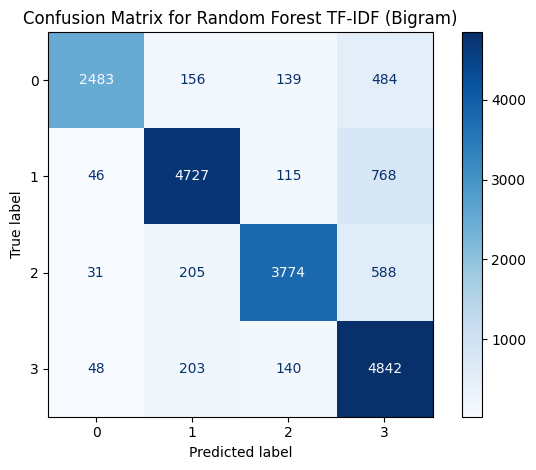

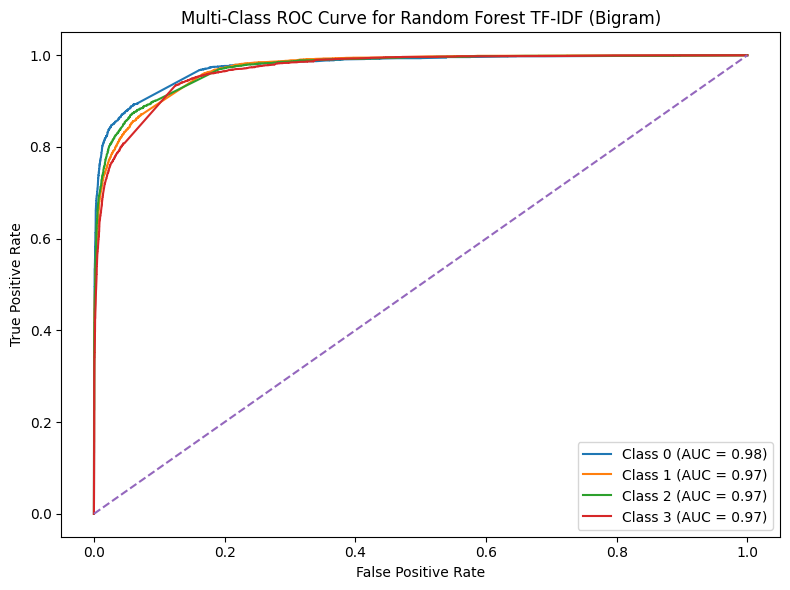

In [159]:
generate_evaluation(random_forest_tfidf_bigram, "Random Forest TF-IDF (Bigram)")

# Count Vectorizer MultiNomial NaiveBayes

Naive Bayes Count Vectorizer (Unigram) Evaluation:

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.63      0.72      3262
           1       0.70      0.85      0.76      5656
           2       0.81      0.65      0.72      4598
           3       0.72      0.79      0.76      5233

    accuracy                           0.75     18749
   macro avg       0.77      0.73      0.74     18749
weighted avg       0.76      0.75      0.74     18749





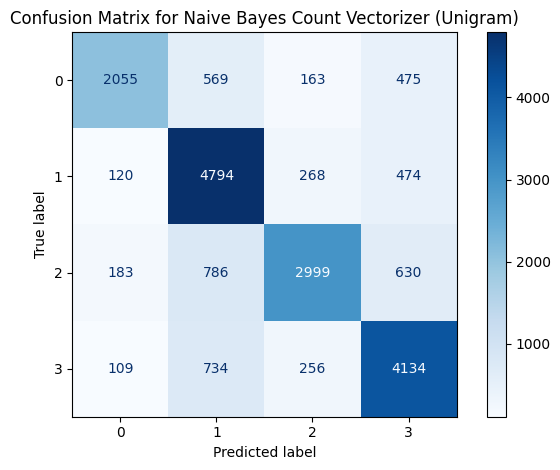

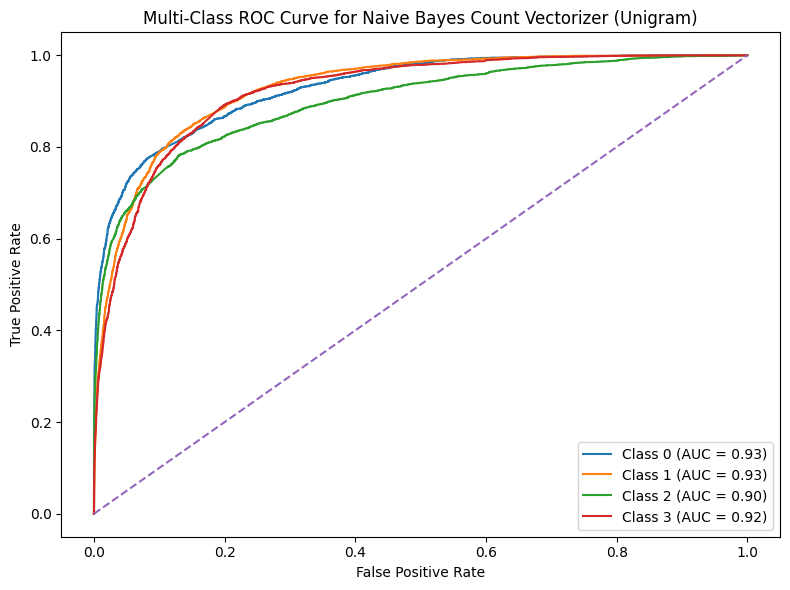

In [160]:
generate_evaluation(multinomialNB_cv, "Naive Bayes Count Vectorizer (Unigram)")

Naive Bayes Count Vectorizer (Bigram) Evaluation:

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.86      0.92      3262
           1       0.80      0.96      0.87      5656
           2       0.95      0.89      0.92      4598
           3       0.93      0.85      0.89      5233

    accuracy                           0.89     18749
   macro avg       0.91      0.89      0.90     18749
weighted avg       0.90      0.89      0.90     18749





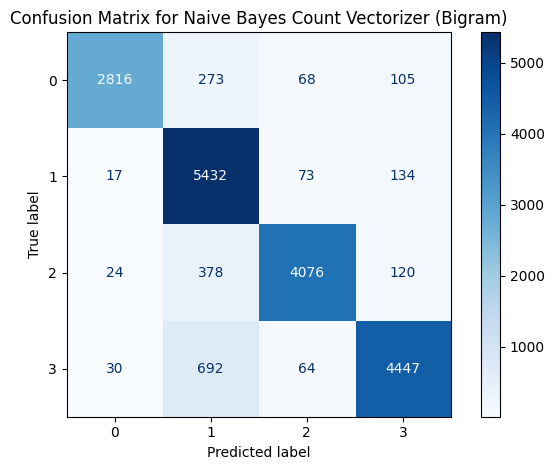

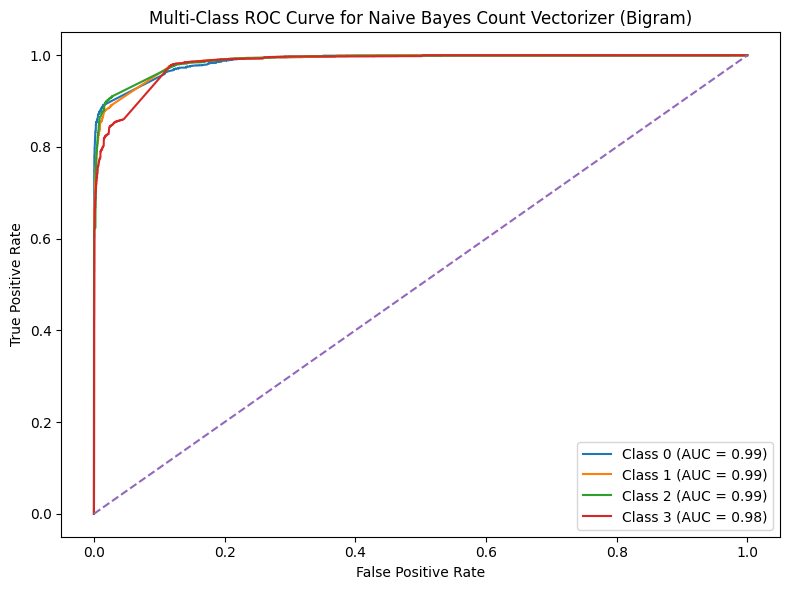

In [161]:
generate_evaluation(multinomialNB_cv_bigram, "Naive Bayes Count Vectorizer (Bigram)")

# TF-IDF MultiNomial NaiveBayes

Naive Bayes TF-IDF (Unigram) Evaluation:

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.43      0.59      3262
           1       0.65      0.89      0.75      5656
           2       0.84      0.63      0.72      4598
           3       0.70      0.80      0.75      5233

    accuracy                           0.72     18749
   macro avg       0.79      0.69      0.70     18749
weighted avg       0.76      0.72      0.72     18749





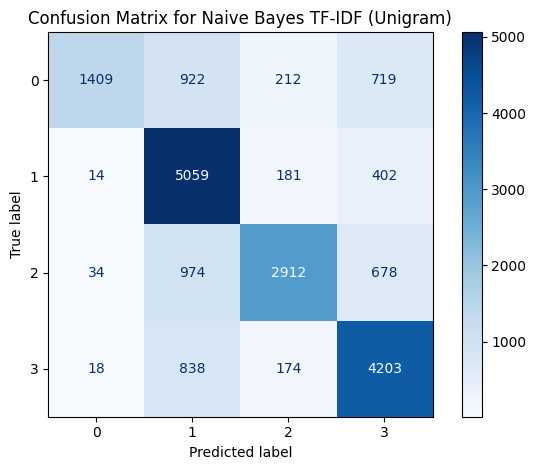

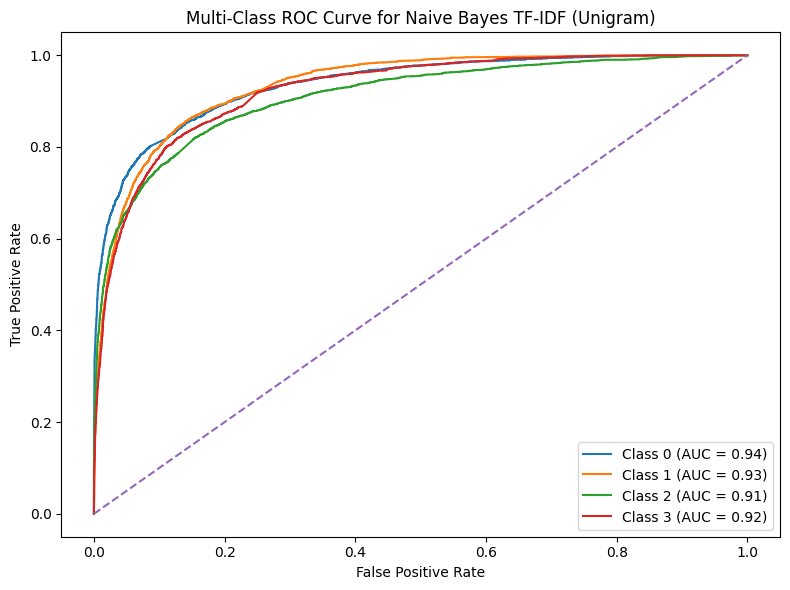

In [162]:
generate_evaluation(multinomialNB_tfidf, "Naive Bayes TF-IDF (Unigram)")

Naive Bayes TF-IDF (Bigram) Evaluation:

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.79      0.88      3262
           1       0.78      0.97      0.87      5656
           2       0.95      0.87      0.91      4598
           3       0.91      0.85      0.88      5233

    accuracy                           0.88     18749
   macro avg       0.91      0.87      0.88     18749
weighted avg       0.90      0.88      0.88     18749





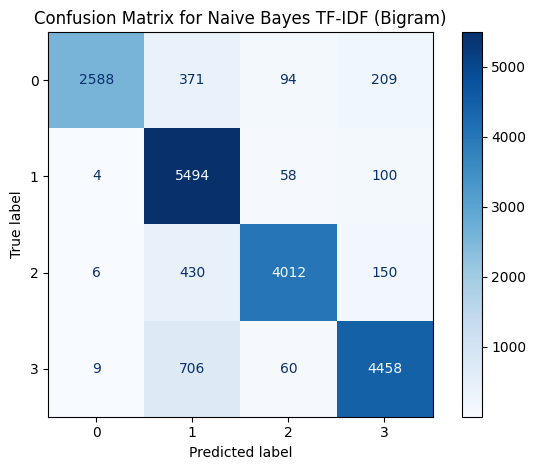

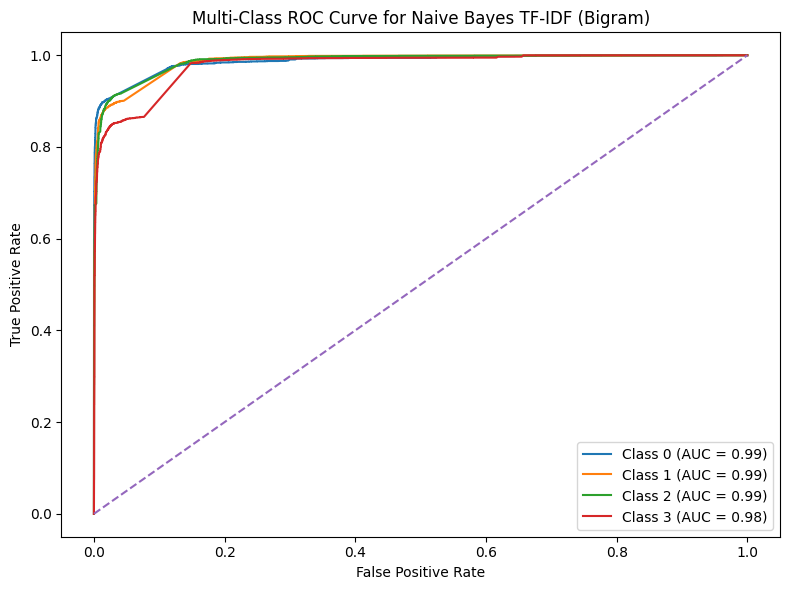

In [163]:
generate_evaluation(multinomialNB_tfidf_bigram, "Naive Bayes TF-IDF (Bigram)")

In [164]:
result_df = result_df.sort_values(by='accuracy', ascending=False).reset_index(drop=True)
result_df

,model name,accuracy,precision,recall,f1
0,Random Forest Count Vectorizer (Unigram),0.91,0.91,0.91,0.91
1,Random Forest TF-IDF (Unigram),0.91,0.92,0.91,0.91
2,Naive Bayes Count Vectorizer (Bigram),0.89,0.90,0.89,0.90
3,Naive Bayes TF-IDF (Bigram),0.88,0.90,0.88,0.88
4,Random Forest Count Vectorizer (Bigram),0.85,0.86,0.85,0.85
5,Random Forest TF-IDF (Bigram),0.84,0.86,0.84,0.85
6,Naive Bayes Count Vectorizer (Unigram),0.75,0.76,0.75,0.74
7,Naive Bayes TF-IDF (Unigram),0.72,0.76,0.72,0.72


In [169]:
def labels(ax):
    for container in ax.containers:
        ax.bar_label(container, labels=[f"{v * 100:.2f}" for v in container.datavalues], padding=3)                   
    
def generate_performance_bar(df, title="Model Performance Comparison"):
    metrics = ['recall', 'precision', 'f1', 'accuracy']

    fig, axs = plt.subplots(4, 1, figsize=(14, 14))

    for i, metric in enumerate(metrics):
        df = df.sort_values(by=metric, ascending=False)
        ax = sns.barplot(x=metric, y="model name", hue="model name", legend=False, data=df, palette="Blues_d", ax=axs[i])
        ax.set_xlabel("")
        ax.set_title(metric.capitalize())
        labels(ax)
    plt.suptitle(title, y=1)        
    plt.tight_layout()
    plt.show()

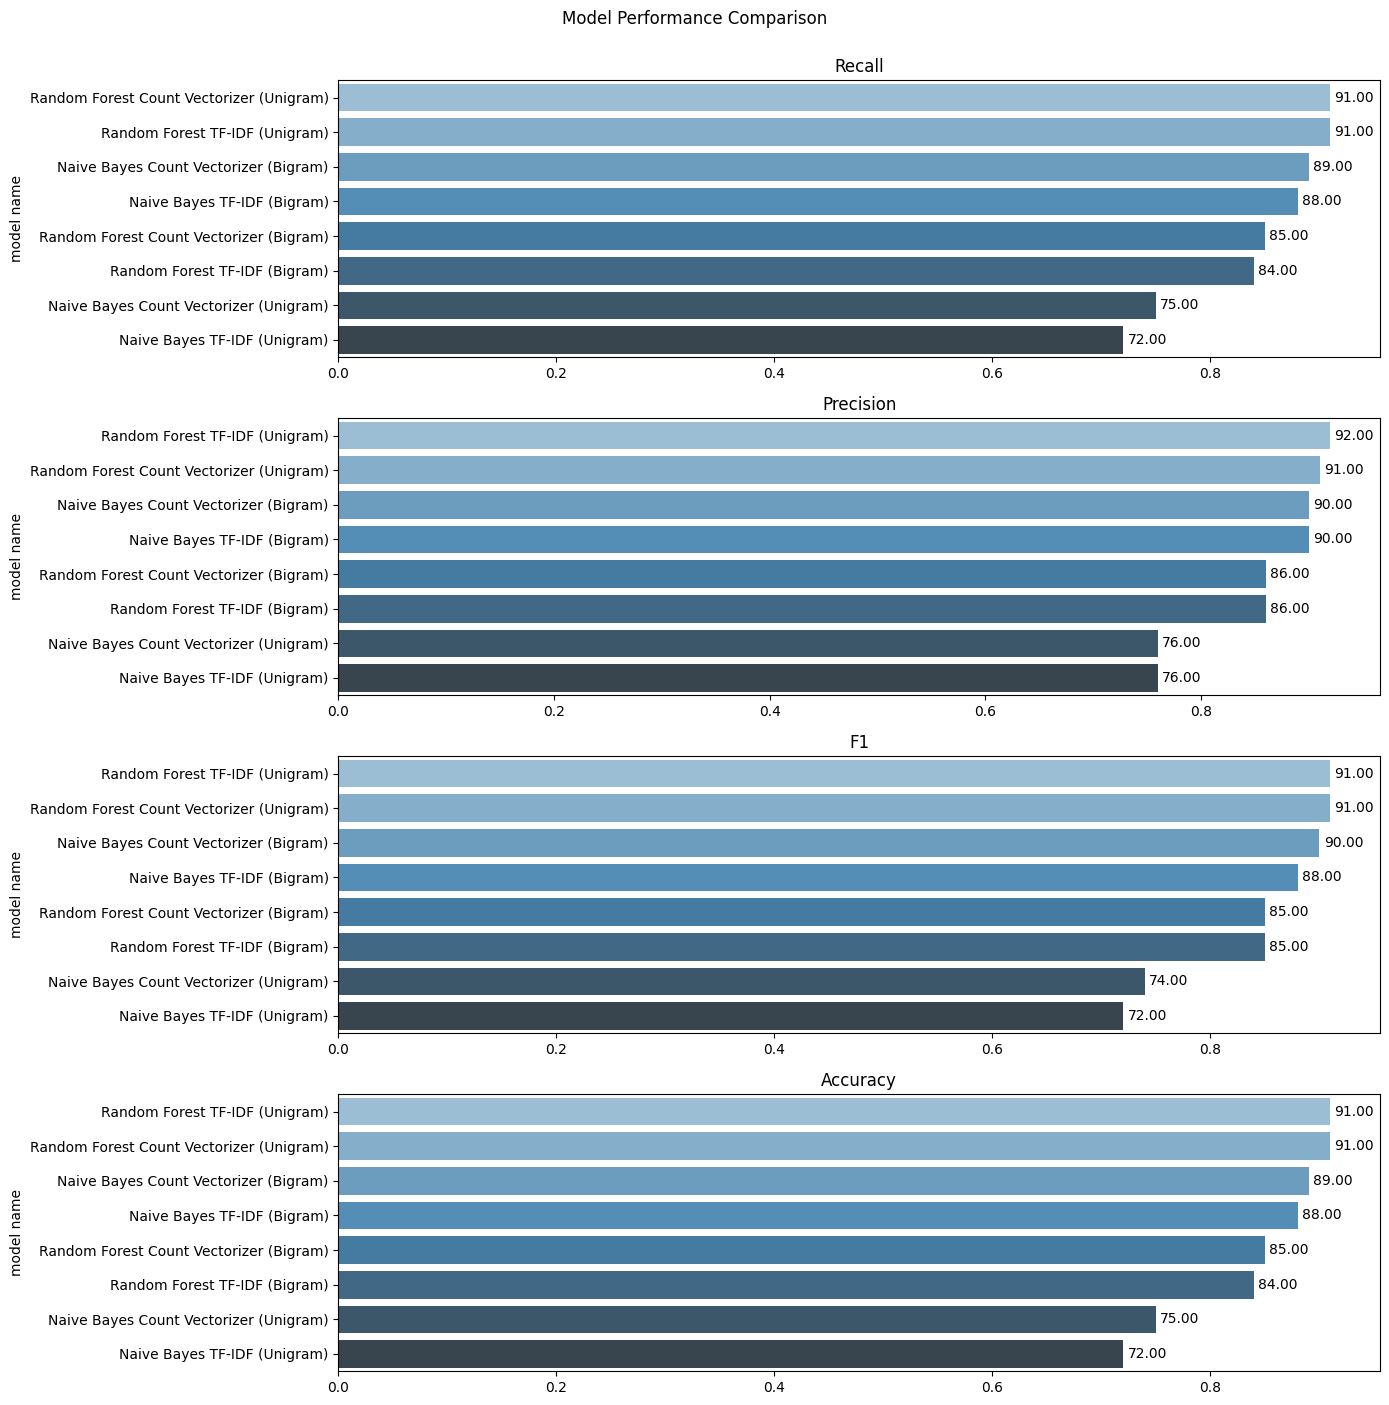

In [170]:
generate_performance_bar(result_df)